# Feature Engineering

In this section, we construct new predictive features from raw customer data.

The goal is to:
- Capture hidden behavioral patterns
- Improve model interpretability
- Increase predictive power
- Translate business logic into machine learning signals

We design 10 custom features based on:
- Customer tenure behavior
- Service usage patterns
- Billing and payment behavior
- Risk and loyalty indicators

Each feature is accompanied by a short business hypothesis explaining why it may help predict customer churn.

In [1]:
import pandas as pd

df = pd.read_csv("../data/train.csv")

# Data Cleaning (Based on EDA)

From EDA, we found no explicit missing values, but `TotalCharges` had hidden missing values stored as empty strings.

We converted it to numeric and handled the resulting NaN values before modeling.

In [2]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isnull().sum()

np.int64(8)

In [3]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

## TenureRange
We convert continuous tenure into meaningful customer lifecycle groups.

In [4]:
bins = [0, 12, 24, 36, 48, 60, float("inf")]
labels = ["0-12", "12-24", "24-36", "36-48", "48-60", "60+"]

df["TenureRange"] = pd.cut(df["tenure"], bins=bins, labels=labels)
df["TenureRange"].value_counts().sort_index()

TenureRange
0-12     1729
12-24     818
24-36     669
36-48     621
48-60     658
60+      1131
Name: count, dtype: int64

Customer lifecycle grouping (new vs loyal customers).

## TotalServices
We count the number of active services per customer.

In [5]:
service_cols = [
"PhoneService","OnlineSecurity","OnlineBackup",
"DeviceProtection","TechSupport","StreamingTV","StreamingMovies"
]

df["TotalServices"] = (
    (df["PhoneService"] == "Yes").astype(int) +
    (df["OnlineSecurity"] == "Yes").astype(int) +
    (df["OnlineBackup"] == "Yes").astype(int) +
    (df["DeviceProtection"] == "Yes").astype(int) +
    (df["TechSupport"] == "Yes").astype(int) +
    (df["StreamingTV"] == "Yes").astype(int) +
    (df["StreamingMovies"] == "Yes").astype(int)
)

In [6]:
df["TotalServices"].describe()

count    5634.000000
mean        2.958821
std         1.849784
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max         7.000000
Name: TotalServices, dtype: float64

Captures overall service adoption strength.

## Security
Combination of OnlineSecurity and DeviceProtection.

In [7]:
df["Security"] = (
    (df["OnlineSecurity"] == "Yes") &
    (df["DeviceProtection"] == "Yes")
).astype(int)
df["Security"].value_counts()

Security
0    4753
1     881
Name: count, dtype: int64

Detects customers with strong security engagement.

## Entertainment
StreamingTV and StreamingMovies together.

In [8]:
df["Entertainment"] = (
    (df["StreamingTV"] == "Yes") &
    (df["StreamingMovies"] == "Yes")
).astype(int)
df["Entertainment"].value_counts()

Entertainment
0    4057
1    1577
Name: count, dtype: int64

Identifies heavy streaming users.

## SeniorTechSupport
Senior customers with tech support.

In [9]:
df["SeniorTechSupport"] = (
    (df["SeniorCitizen"] == 1) &
    (df["TechSupport"] == "Yes")
).astype(int)
df["SeniorTechSupport"].value_counts()

SeniorTechSupport
0    5424
1     210
Name: count, dtype: int64

Flags vulnerable users needing support.

## BillingAndPayment
High-risk payment behavior pattern.

In [10]:
df["BillingAndPayment"] = (
    (df["PaperlessBilling"] == "Yes") &
    (df["PaymentMethod"] == "Electronic check")
).astype(int)
df["BillingAndPayment"].value_counts()

BillingAndPayment
0    4244
1    1390
Name: count, dtype: int64

High-risk payment behavior indicator.

## MonthlyChargesRange
We discretize MonthlyCharges into fixed-width bins (20 units) to capture pricing segments.

In [11]:
bins = list(range(0, int(df["MonthlyCharges"].max()) + 20, 20))
labels = [f"{i}-{i+20}" for i in bins[:-1]]

df["MonthlyChargesRange"] = pd.cut(df["MonthlyCharges"], bins=bins, labels=labels, include_lowest=True)
df["MonthlyChargesRange"].value_counts()

MonthlyChargesRange
80-100     1423
60-80      1144
20-40       947
40-60       863
100-120     738
0-20        519
Name: count, dtype: int64

Groups customers by pricing tiers.

## AvgMonthlyPerService
We compute cost efficiency per active service.

In [12]:
df["AvgMonthlyPerService"] = df["MonthlyCharges"] / df["TotalServices"]

median_value = df["MonthlyCharges"].median()
df.loc[df["TotalServices"] == 0, "AvgMonthlyPerService"] = median_value

In [13]:
df["AvgMonthlyPerService"].describe()

count    5634.000000
mean       26.387755
std        14.361658
min        10.416667
25%        18.383333
50%        20.860000
75%        28.579167
max        77.900000
Name: AvgMonthlyPerService, dtype: float64

Measures cost efficiency per service usage.

## TenureContractRisk
We flag high-risk customers with short tenure and month-to-month contracts.

In [14]:
df["TenureContractRisk"] = (
    (df["Contract"] == "Month-to-month") &
    (df["tenure"] <= 12)
).astype(int)
df["TenureContractRisk"].value_counts()

TenureContractRisk
0    4040
1    1594
Name: count, dtype: int64

High churn risk segment detector.

## LoyaltyFactor
We build a 1–5 loyalty score based on tenure and contract stability.

In [15]:
def loyalty_score(row):
    if row["Contract"] == "Month-to-month":
        if row["tenure"] <= 12:
            return 1
        elif row["tenure"] <= 24:
            return 2
        else:
            return 3
    elif row["Contract"] == "One year":
        if row["tenure"] <= 24:
            return 3
        else:
            return 4
    else:
        return 5

df["LoyaltyFactor"] = df.apply(loyalty_score, axis=1)
df["LoyaltyFactor"].value_counts()

LoyaltyFactor
1    1594
5    1359
3    1182
4     919
2     580
Name: count, dtype: int64

Compact loyalty scoring from contract + tenure.

We successfully engineered 10 domain-driven features capturing:
- Customer lifecycle (TenureRange, LoyaltyFactor)
- Service engagement (TotalServices, Entertainment, Security)
- Financial behavior (BillingAndPayment, AvgMonthlyPerService)
- Risk signals (TenureContractRisk, SeniorTechSupport)
- Pricing segmentation (MonthlyChargesRange)

These features transform raw telecom data into structured behavioral signals for churn prediction.

# Data Preprocessing

In this stage, we prepare the dataset for machine learning models.

The main goal is to convert raw and structured data into a clean numerical format suitable for training.

We ensure:
- No data leakage between training and test sets
- Proper encoding of categorical variables
- Scaling of numerical features
- Consistent transformation pipeline for reproducibility

This step is critical because machine learning models can only learn from numerical inputs, and improper preprocessing can lead to misleading performance results.

## Remove identifier column
We drop customerID because it has no predictive value.

In [16]:
df = df.drop("customerID", axis=1)

In [17]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TenureRange,TotalServices,Security,Entertainment,SeniorTechSupport,BillingAndPayment,MonthlyChargesRange,AvgMonthlyPerService,TenureContractRisk,LoyaltyFactor
0,Male,0,No,No,35,No,No phone service,DSL,No,No,...,24-36,3,0,1,0,0,40-60,16.400000,0,3
1,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,...,12-24,2,0,0,0,0,60-80,37.550000,0,2
2,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,Yes,...,12-24,3,0,0,0,0,40-60,13.516667,0,5
3,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,...,24-36,5,0,1,0,0,60-80,14.700000,0,5
4,Male,0,Yes,Yes,1,Yes,No,DSL,No,No,...,0-12,1,0,0,0,0,40-60,44.550000,1,1


## Train/Validation Split
We split data before encoding to avoid data leakage.

In [18]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"].map({"No":0, "Yes":1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Feature Type Identification
We separate categorical and numerical features.

In [19]:
num_features = ["tenure","MonthlyCharges","TotalCharges",
                "TotalServices","AvgMonthlyPerService"]

cat_features = [col for col in X.columns if col not in num_features]

## Preprocessing Pipeline
We ensure transformations are fit only on training data to prevent leakage.

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

In [21]:
X_train_processed = preprocess.fit_transform(X_train)
X_test_processed = preprocess.transform(X_test)

In [22]:
X_train_processed.shape, X_test_processed.shape

((4507, 76), (1127, 76))

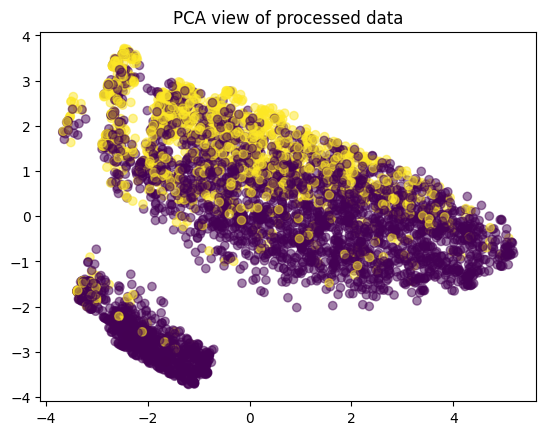

In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_train_processed)

plt.scatter(X_vis[:,0], X_vis[:,1], c=y_train, alpha=0.5)
plt.title("PCA view of processed data")
plt.show()

## PCA Visualization of Processed Data

We applied PCA to reduce the high-dimensional feature space to 2 components for visualization.

### Key Observation:
- The data forms partially separated clusters in the 2D PCA space.
- However, churn classes (Yes/No) are still heavily mixed within both clusters.

### Conclusion:
Feature engineering and preprocessing successfully structured the data, but churn remains a non-linearly separable problem in 2D space.

# Class Imbalance Mitigation

The target variable is imbalanced, which may bias classifiers toward the majority class.

We first establish a baseline model without any imbalance handling techniques. This baseline will serve as a reference point for evaluating the impact of oversampling and class-weighting strategies.

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

rf_baseline = RandomForestClassifier(random_state=42)

rf_baseline.fit(X_train_processed, y_train)

y_pred_baseline = rf_baseline.predict(X_test_processed)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_baseline))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

Confusion Matrix:
[[748  80]
 [159 140]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       828
           1       0.64      0.47      0.54       299

    accuracy                           0.79      1127
   macro avg       0.73      0.69      0.70      1127
weighted avg       0.77      0.79      0.78      1127



The baseline Random Forest achieved reasonable overall accuracy (79%), but performance on the minority class is noticeably weaker.

### Key Observation
- Churn recall = 47%
- Churn F1-score = 54%

### Conclusion
The model favors the majority class and fails to identify more than half of churning customers. This motivates the use of class imbalance mitigation techniques.

# Synthetic Oversampling with SMOTE

To improve detection of the minority class, we apply SMOTE (Synthetic Minority Oversampling Technique) on the training data.

SMOTE generates synthetic minority samples and helps the classifier learn a more balanced decision boundary.

In [31]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print(y_train.value_counts())
print()
print(y_train_smote.value_counts())

Churn
0    3311
1    1196
Name: count, dtype: int64

Churn
0    3311
1    3311
Name: count, dtype: int64


The training set is now perfectly balanced, allowing the model to learn minority-class patterns more effectively

In [33]:
rf_smote = RandomForestClassifier(random_state=42)

rf_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = rf_smote.predict(X_test_processed)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))

Confusion Matrix:
[[724 104]
 [131 168]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       828
           1       0.62      0.56      0.59       299

    accuracy                           0.79      1127
   macro avg       0.73      0.72      0.72      1127
weighted avg       0.79      0.79      0.79      1127



After applying SMOTE, the model became more effective at identifying churners.

- Recall: 0.47 → 0.56
- F1-score: 0.54 → 0.59

SMOTE improved minority-class detection at the cost of a slight increase in false positives. This trade-off is often desirable in churn prediction tasks where missing a churner is more costly than contacting a loyal customer.

# Cost-Sensitive Learning

Instead of generating synthetic samples, we can directly penalize mistakes on the minority class by assigning class weights inversely proportional to class frequencies.

This encourages the model to pay more attention to churners during training.